In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [73]:
df = pd.read_csv("dermatology_database_1.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (366, 35)


In [74]:
print(df.head())

   erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0         2        2                 0        3                   0   
1         3        3                 3        2                   1   
2         2        1                 2        3                   1   
3         2        2                 2        0                   0   
4         2        3                 2        2                   2   

   polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  0                   0                         0   
1                  0                   0                         0   
2                  3                   0                         3   
3                  0                   0                         0   
4                  2                   0                         2   

   knee_and_elbow_involvement  scalp_involvement  ...  \
0                           1                  0  ...   
1                           1         

In [75]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   erythema                             366 non-null    int64
 1   scaling                              366 non-null    int64
 2   definite_borders                     366 non-null    int64
 3   itching                              366 non-null    int64
 4   koebner_phenomenon                   366 non-null    int64
 5   polygonal_papules                    366 non-null    int64
 6   follicular_papules                   366 non-null    int64
 7   oral_mucosal_involvement             366 non-null    int64
 8   knee_and_elbow_involvement           366 non-null    int64
 9   scalp_involvement                    366 non-null    int64
 10  family_history                       366 non-null    int64
 11  melanin_incontinence                 366 non-null    int64
 12  eosin

In [76]:
print(df.columns.tolist())

['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_rete_ridges', 'elongation_rete_ridges', 'thinning_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_granular_layer', 'vacuolisation_damage_basal_layer', 'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate', 'band_like_infiltrate', 'age', 'class']


In [77]:
df = df.replace("?", np.nan)

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df.isnull().sum())

erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess                      0
focal_hypergranu

In [78]:
target_column = "class"

feature_columns = [
    column for column in df.columns
    if column != target_column
]

print("Target:", target_column)
print("Number of features:", len(feature_columns))

Target: class
Number of features: 34


In [79]:
print("Total missing values before handling:",
      df.isnull().sum().sum())

df[feature_columns] = df[feature_columns].fillna(
    df[feature_columns].median()
)

print("Total missing values after handling:",
      df.isnull().sum().sum())

Total missing values before handling: 8
Total missing values after handling: 0


In [80]:
print("Number of duplicate rows:",
      df.duplicated().sum())

Number of duplicate rows: 0


In [81]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:",
      df.shape)

Shape after removing duplicates: (366, 35)


In [82]:
summary = df[feature_columns].describe().T

summary["median"] = df[feature_columns].median()
summary["variance"] = df[feature_columns].var()

display(summary)

,count,mean,std,min,25%,50%,75%,max,median,variance
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0,2.0,0.441897
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0,2.0,0.492140
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.0,3.0,2.0,0.823602
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.0,3.0,1.0,1.295726
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.0,3.0,0.0,0.824493
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0,0.0,0.916476
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0,0.0,0.325571
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0,0.0,0.695801
knee_and_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0,0.0,0.966247
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0,0.0,0.820181


In [83]:
print("Mean:")
display(df[feature_columns].mean())

Mean:


erythema                                2.068306
scaling                                 1.795082
definite_borders                        1.549180
itching                                 1.366120
koebner_phenomenon                      0.633880
polygonal_papules                       0.448087
follicular_papules                      0.166667
oral_mucosal_involvement                0.377049
knee_and_elbow_involvement              0.614754
scalp_involvement                       0.519126
family_history                          0.125683
melanin_incontinence                    0.404372
eosinophils_infiltrate                  0.139344
PNL_infiltrate                          0.546448
fibrosis_papillary_dermis               0.336066
exocytosis                              1.368852
acanthosis                              1.956284
hyperkeratosis                          0.527322
parakeratosis                           1.289617
clubbing_rete_ridges                    0.663934
elongation_rete_ridg

In [84]:
print("Median:")
display(df[feature_columns].median())

Median:


erythema                                2.0
scaling                                 2.0
definite_borders                        2.0
itching                                 1.0
koebner_phenomenon                      0.0
polygonal_papules                       0.0
follicular_papules                      0.0
oral_mucosal_involvement                0.0
knee_and_elbow_involvement              0.0
scalp_involvement                       0.0
family_history                          0.0
melanin_incontinence                    0.0
eosinophils_infiltrate                  0.0
PNL_infiltrate                          0.0
fibrosis_papillary_dermis               0.0
exocytosis                              2.0
acanthosis                              2.0
hyperkeratosis                          0.0
parakeratosis                           1.0
clubbing_rete_ridges                    0.0
elongation_rete_ridges                  0.0
thinning_suprapapillary_epidermis       0.0
spongiform_pustule              

In [85]:
print("Standard Deviation:")
display(df[feature_columns].std())

Standard Deviation:


erythema                                0.664753
scaling                                 0.701527
definite_borders                        0.907525
itching                                 1.138299
koebner_phenomenon                      0.908016
polygonal_papules                       0.957327
follicular_papules                      0.570588
oral_mucosal_involvement                0.834147
knee_and_elbow_involvement              0.982979
scalp_involvement                       0.905639
family_history                          0.331946
melanin_incontinence                    0.869818
eosinophils_infiltrate                  0.411790
PNL_infiltrate                          0.815451
fibrosis_papillary_dermis               0.853139
exocytosis                              1.104418
acanthosis                              0.712512
hyperkeratosis                          0.757116
parakeratosis                           0.917562
clubbing_rete_ridges                    1.056829
elongation_rete_ridg

In [86]:
Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df[feature_columns] < lower_bound) |
    (df[feature_columns] > upper_bound)
)

outlier_counts = outliers.sum()

display(
    outlier_counts.to_frame("Outlier Count")
)

print("Total outlier values:",
      outlier_counts.sum())

,Outlier Count
erythema,151
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,18
polygonal_papules,69
follicular_papules,33
oral_mucosal_involvement,67
knee_and_elbow_involvement,23
scalp_involvement,16


Total outlier values: 1287


In [87]:
df[feature_columns] = df[feature_columns].clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


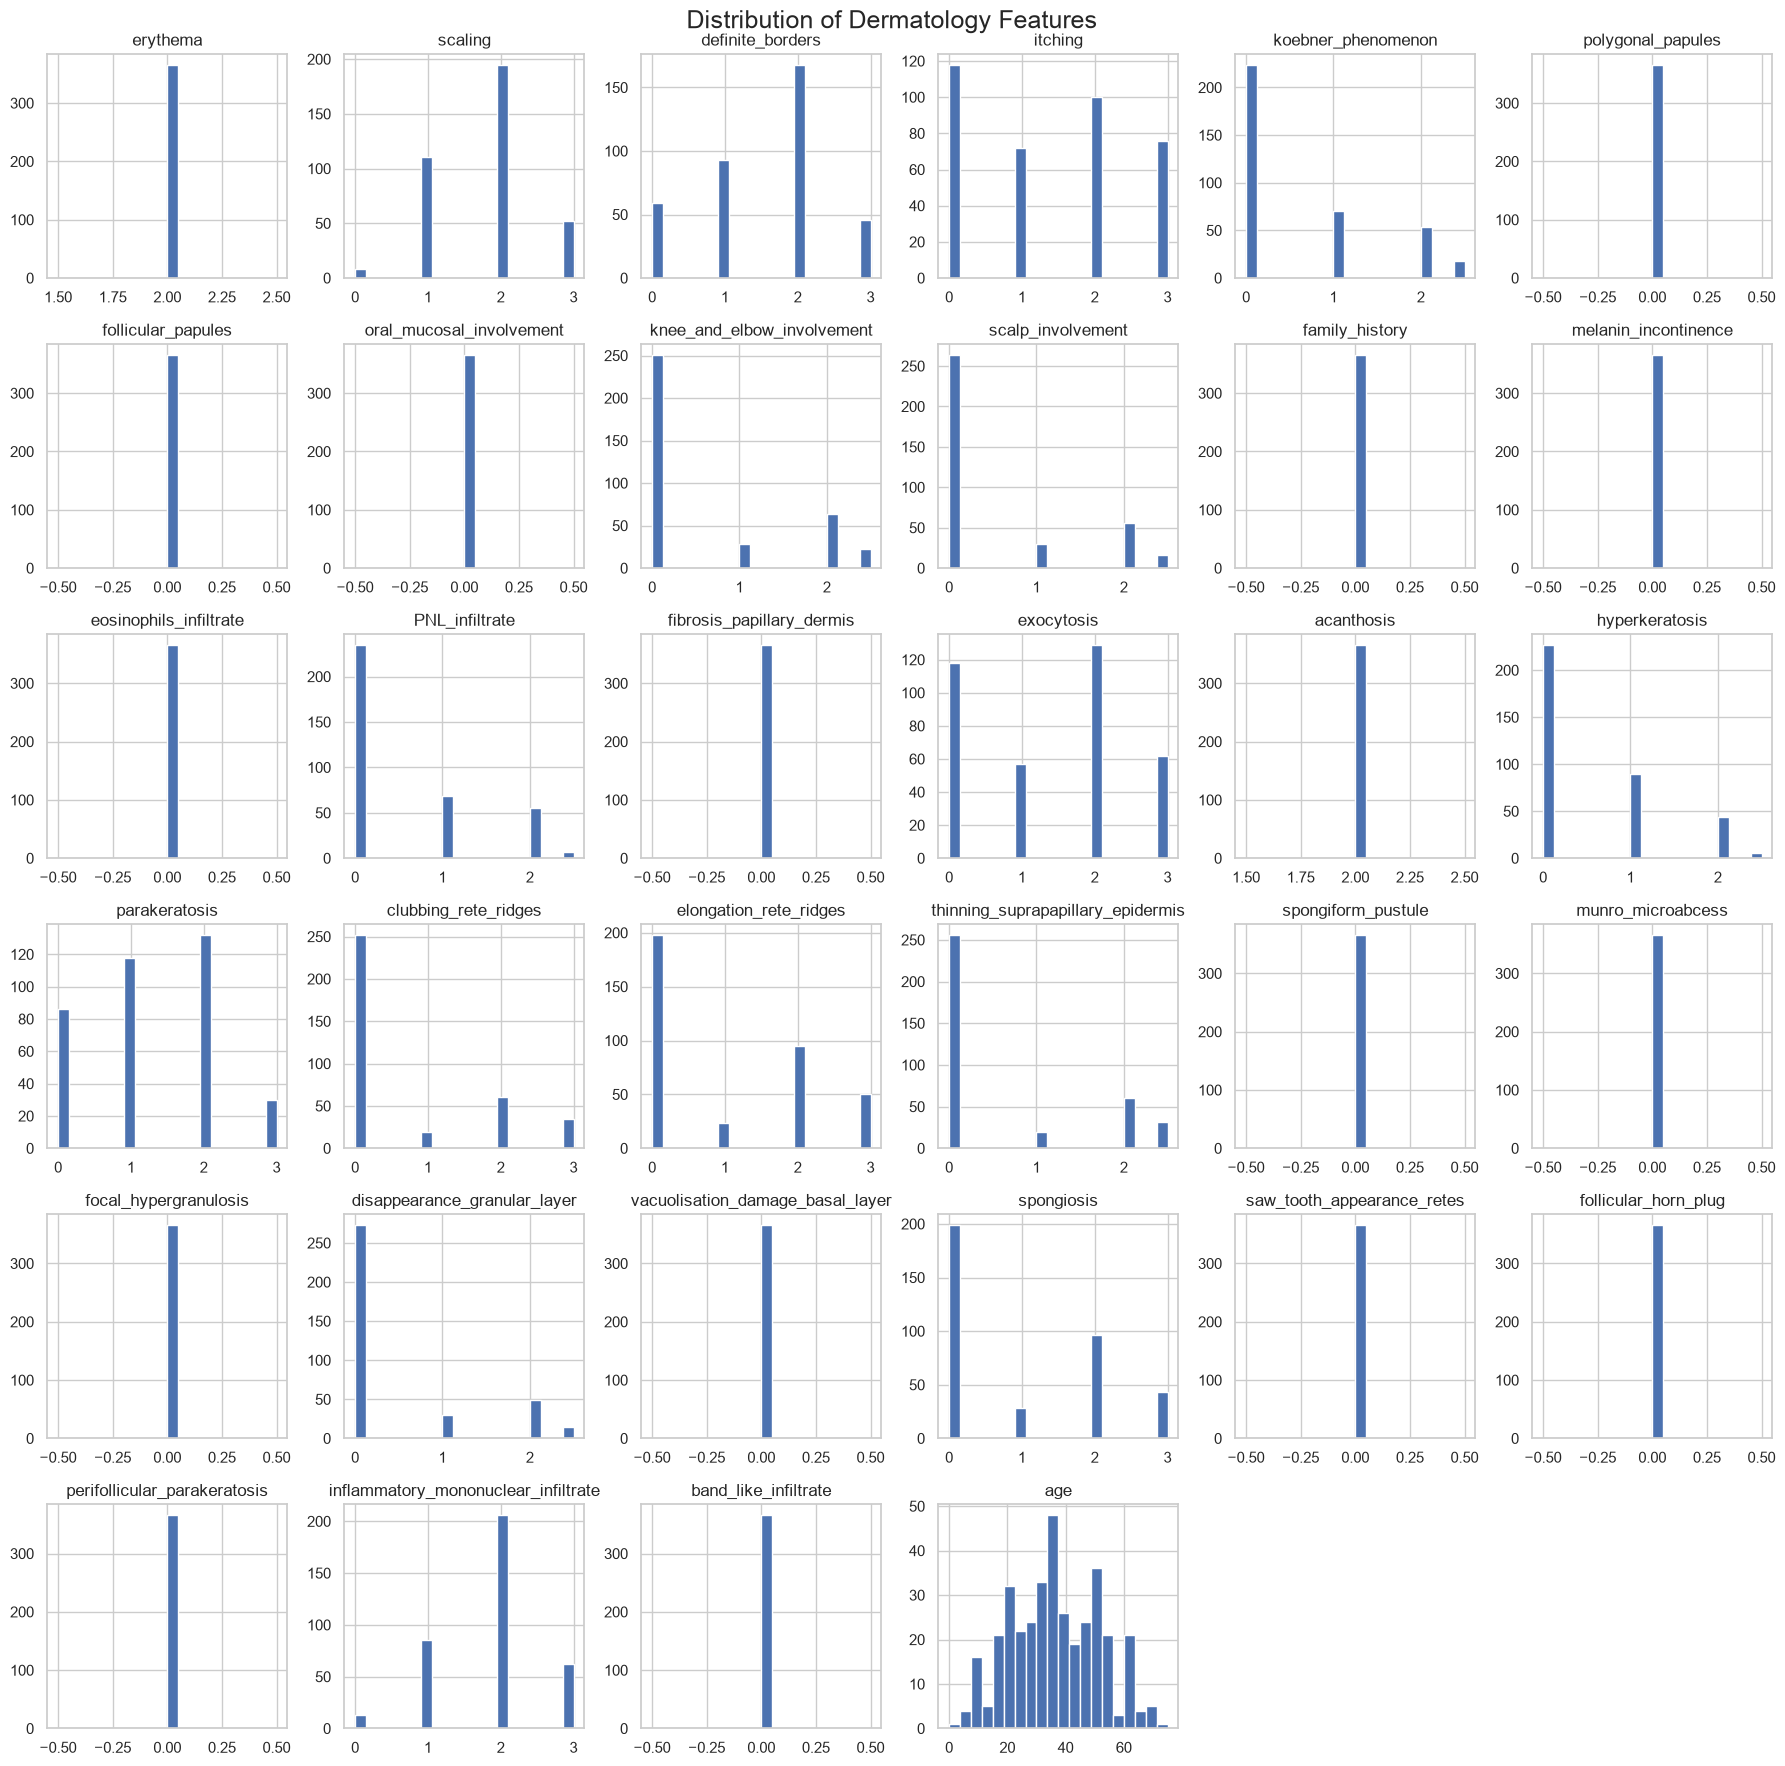

In [88]:
df[feature_columns].hist(
    figsize=(18, 18),
    bins=20
)

plt.suptitle(
    "Distribution of Dermatology Features",
    fontsize=18
)

plt.tight_layout()
plt.show()

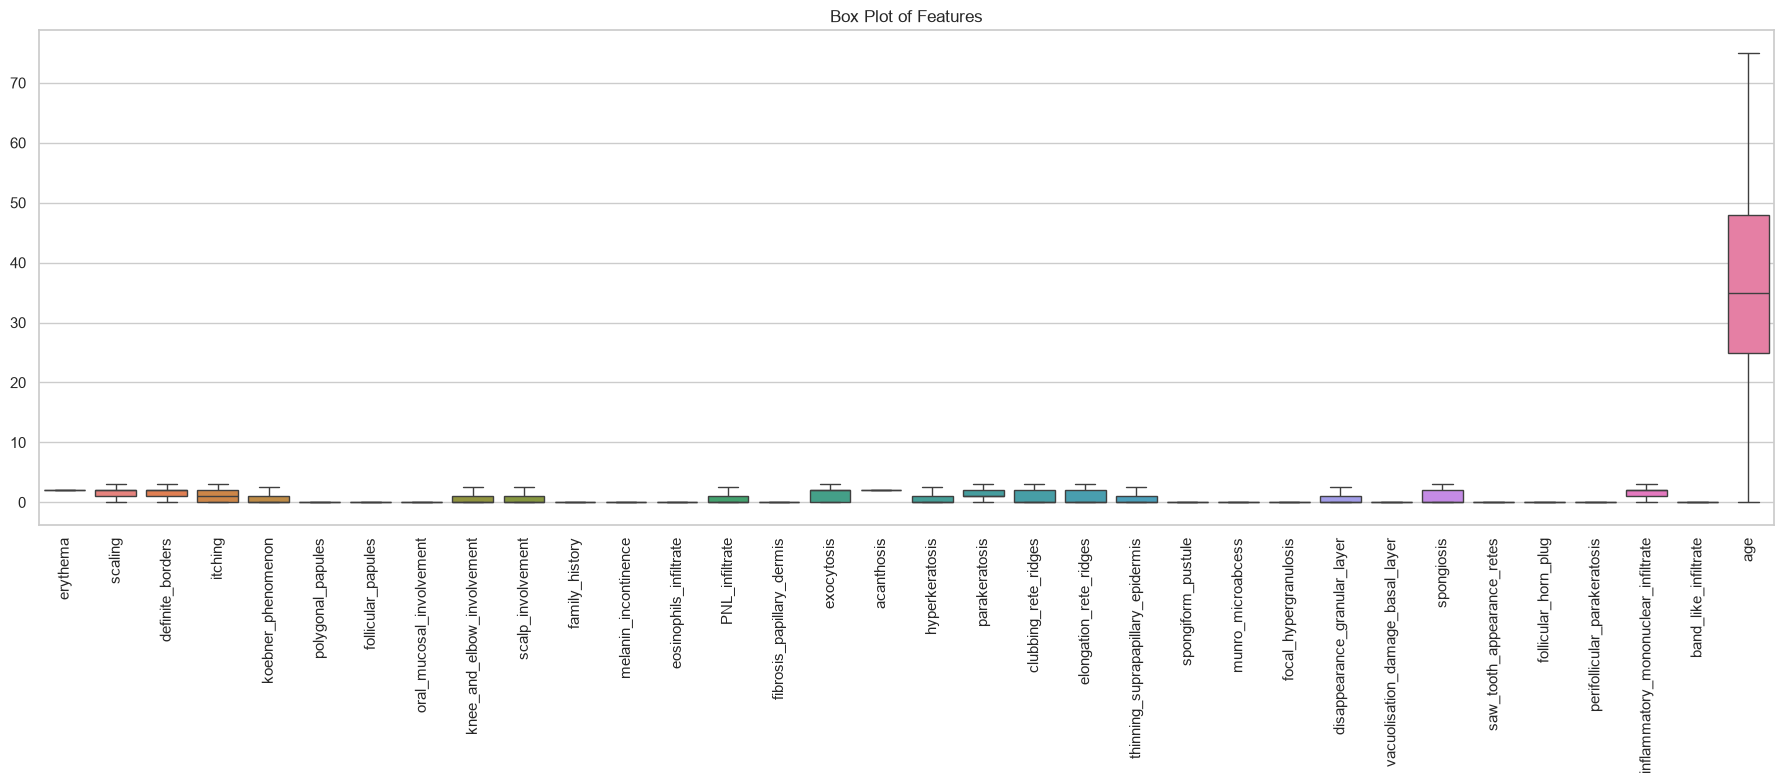

In [89]:
plt.figure(figsize=(18, 8))

sns.boxplot(
    data=df[feature_columns]
)

plt.xticks(rotation=90)
plt.title("Box Plot of Features")
plt.tight_layout()
plt.show()

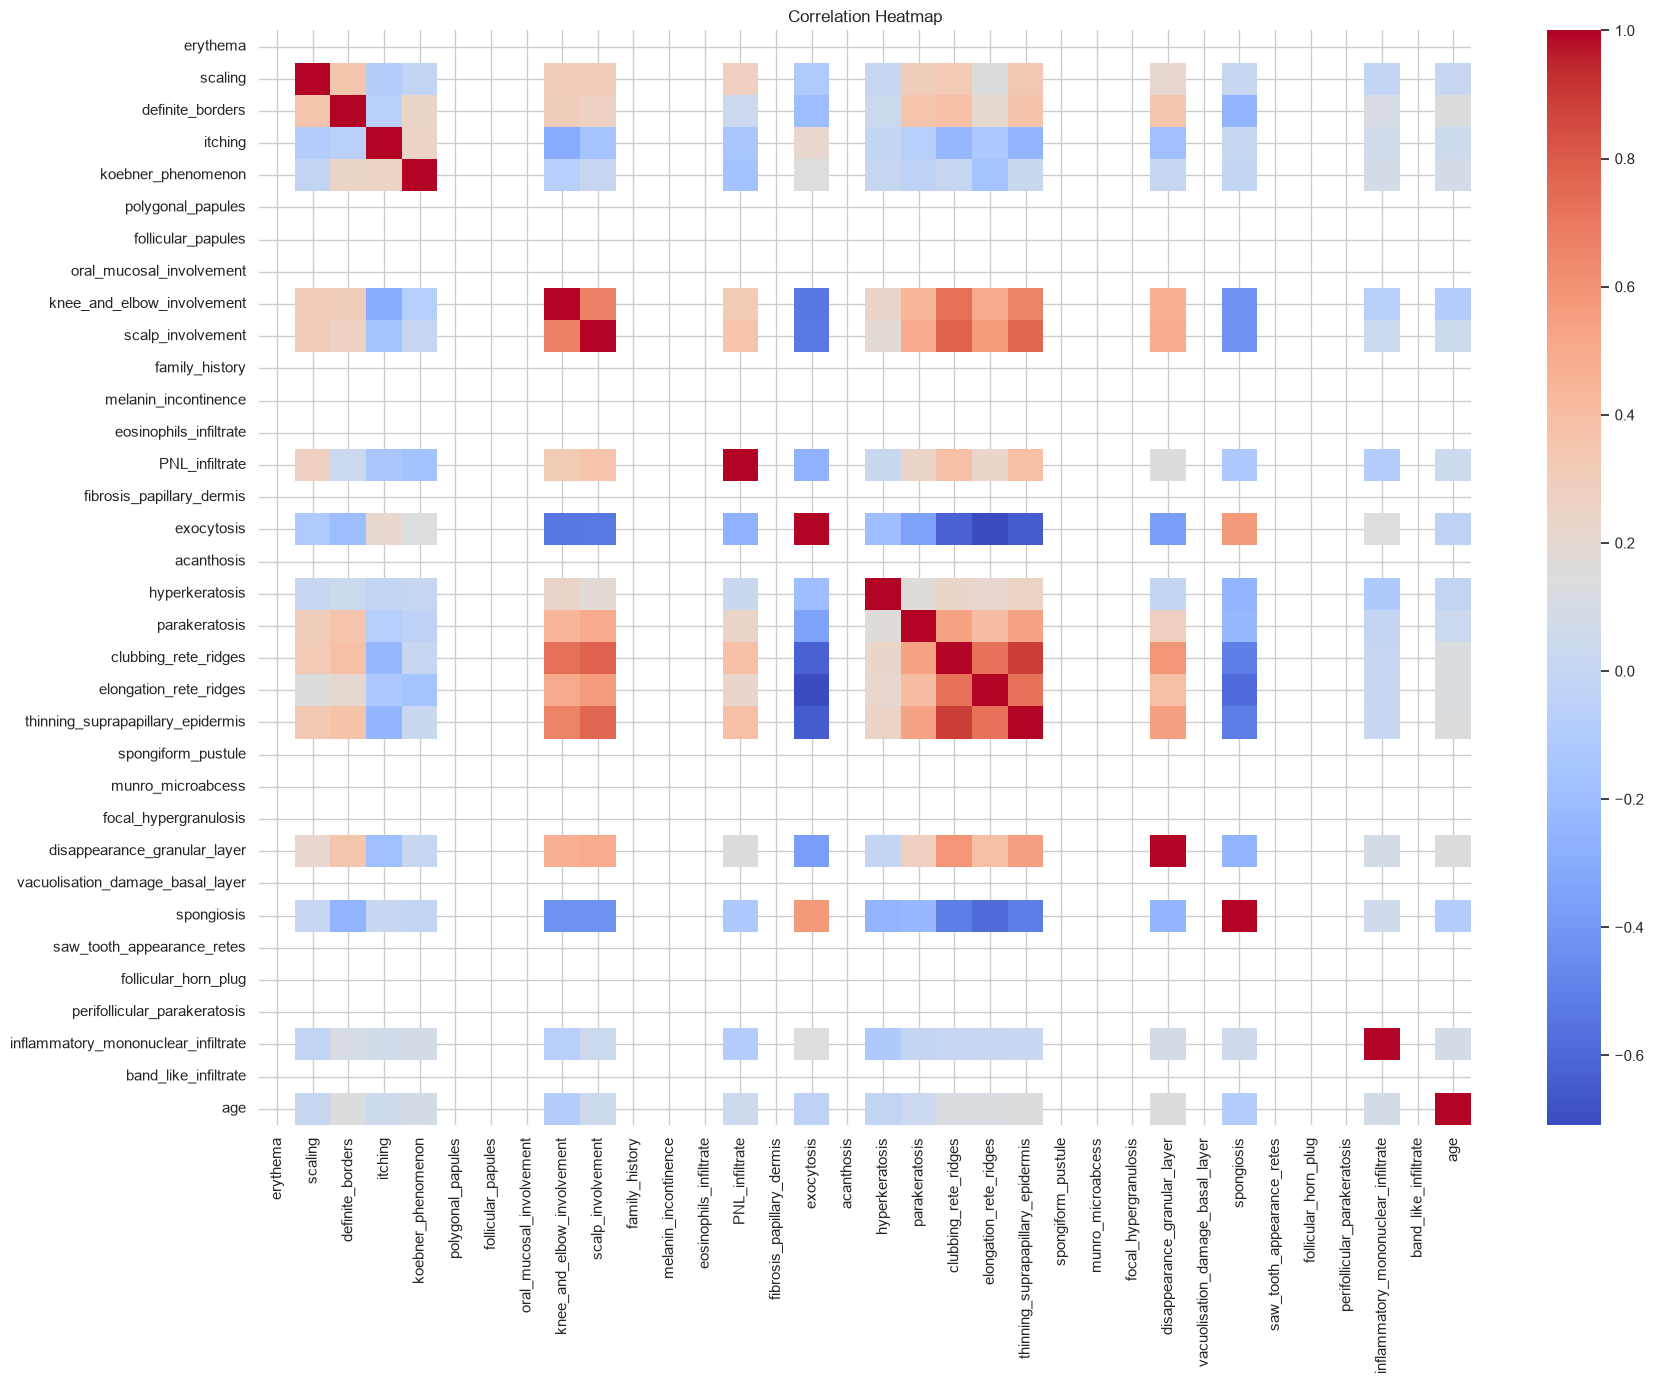

In [90]:
correlation = df[feature_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [91]:
class_counts = df[target_column].value_counts().sort_index()

print("Class Distribution:")
display(class_counts)

Class Distribution:


class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64

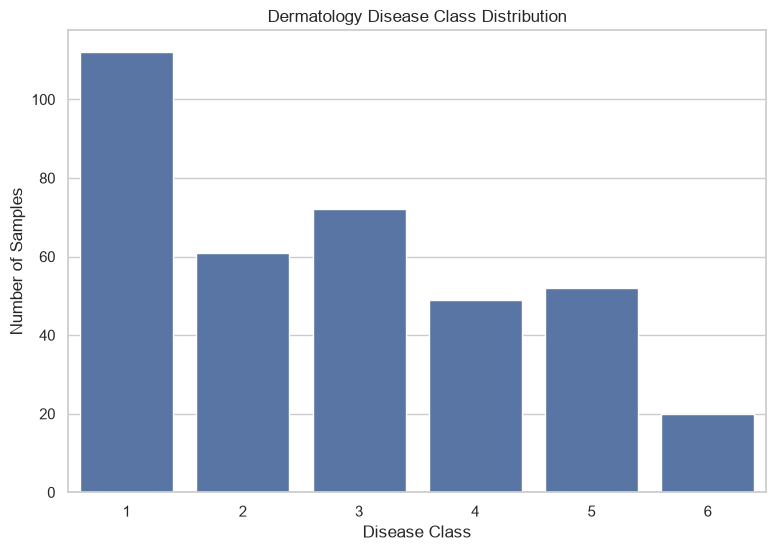

In [92]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x=target_column,
    order=sorted(df[target_column].unique())
)

plt.title("Dermatology Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")

plt.show()

In [93]:
class_percentage = (
    df[target_column]
    .value_counts(normalize=True)
    .sort_index() * 100
)

display(
    class_percentage.to_frame(
        "Percentage"
    )
)

,Percentage
class,
1,30.601093
2,16.666667
3,19.672131
4,13.387978
5,14.207650
6,5.464481


In [94]:
print("Minimum class samples:",
      class_counts.min())

print("Maximum class samples:",
      class_counts.max())

imbalance_ratio = (
    class_counts.max() /
    class_counts.min()
)

print("Imbalance ratio:",
      round(imbalance_ratio, 2))

Minimum class samples: 20
Maximum class samples: 112
Imbalance ratio: 5.6


In [95]:
X = df.drop(columns=[target_column])
y = df[target_column].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(y.unique()))

X shape: (366, 34)
y shape: (366,)
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 292
Testing samples: 74


In [97]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
class
1    89
2    49
3    57
4    39
5    42
6    16
Name: count, dtype: int64

Testing class distribution:
class
1    23
2    12
3    15
4    10
5    10
6     4
Name: count, dtype: int64


In [98]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


In [99]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

print("Models created:")
for name in models:
    print(name)

Models created:
Logistic Regression
KNN
SVM
Random Forest
Decision Tree


In [100]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(name, "trained successfully")

Logistic Regression trained successfully
KNN trained successfully
SVM trained successfully
Random Forest trained successfully
Decision Tree trained successfully


In [101]:
predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_scaled)

print("Predictions generated.")

Predictions generated.


In [102]:
results = []

for name, y_pred in predictions.items():

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.972973,0.969444,0.969444,0.969444
1,Logistic Regression,0.959459,0.957176,0.952778,0.954419
2,Random Forest,0.945946,0.940404,0.944444,0.941872
3,KNN,0.918919,0.917892,0.913889,0.909280
4,Decision Tree,0.905405,0.906926,0.880556,0.887464


In [103]:
for name, y_pred in predictions.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        23
           2     0.9167    0.9167    0.9167        12
           3     0.9375    1.0000    0.9677        15
           4     0.8889    0.8000    0.8421        10
           5     1.0000    1.0000    1.0000        10
           6     1.0000    1.0000    1.0000         4

    accuracy                         0.9595        74
   macro avg     0.9572    0.9528    0.9544        74
weighted avg     0.9588    0.9595    0.9586        74

KNN
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        23
           2     0.8750    0.5833    0.7000        12
           3     0.8824    1.0000    0.9375        15
           4     0.7500    0.9000    0.8182        10
           5     1.0000    1.0000    1.0000        10
           6     1.0000    1.0000    1.0000         4

    accuracy                         0.9189        74

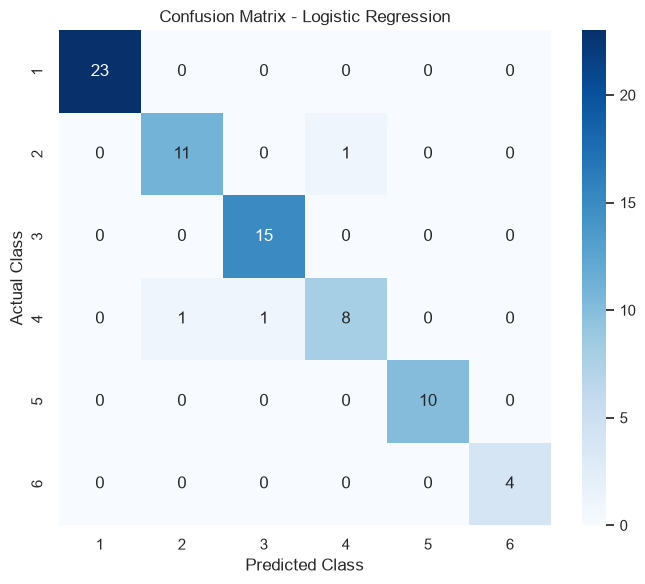

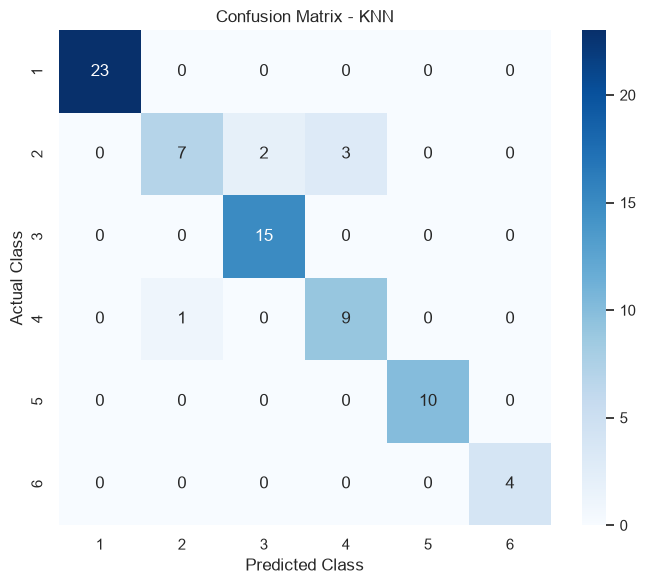

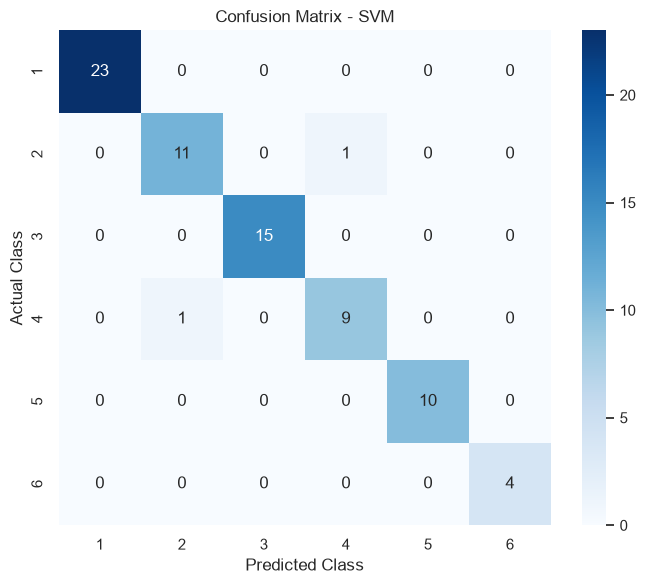

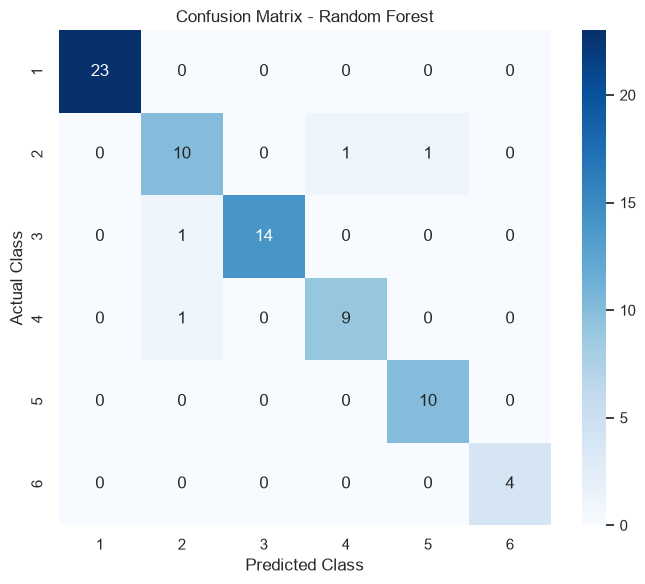

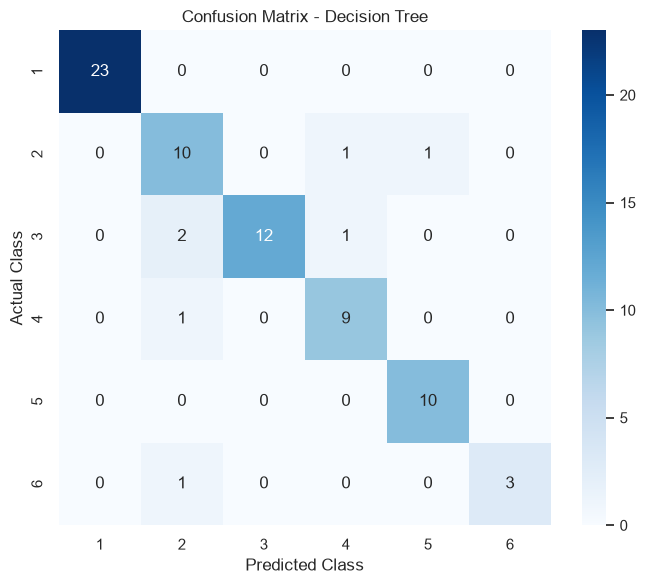

In [104]:
classes = np.sort(y.unique())

for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=classes
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

In [105]:
y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_results = {}

for name, model in trained_models.items():

    y_score = model.predict_proba(
        X_test_scaled
    )

    fpr = {}
    tpr = {}
    class_auc = {}

    for i, class_label in enumerate(classes):

        fpr[class_label], tpr[class_label], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        class_auc[class_label] = auc(
            fpr[class_label],
            tpr[class_label]
        )

    macro_auc = roc_auc_score(
        y_test,
        y_score,
        multi_class="ovr",
        average="macro"
    )

    roc_results[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": class_auc,
        "macro_auc": macro_auc
    }

    print(
        name,
        "Macro AUC:",
        round(macro_auc, 4)
    )

Logistic Regression Macro AUC: 0.9975
KNN Macro AUC: 0.9814
SVM Macro AUC: 0.9969
Random Forest Macro AUC: 0.9957
Decision Tree Macro AUC: 0.931


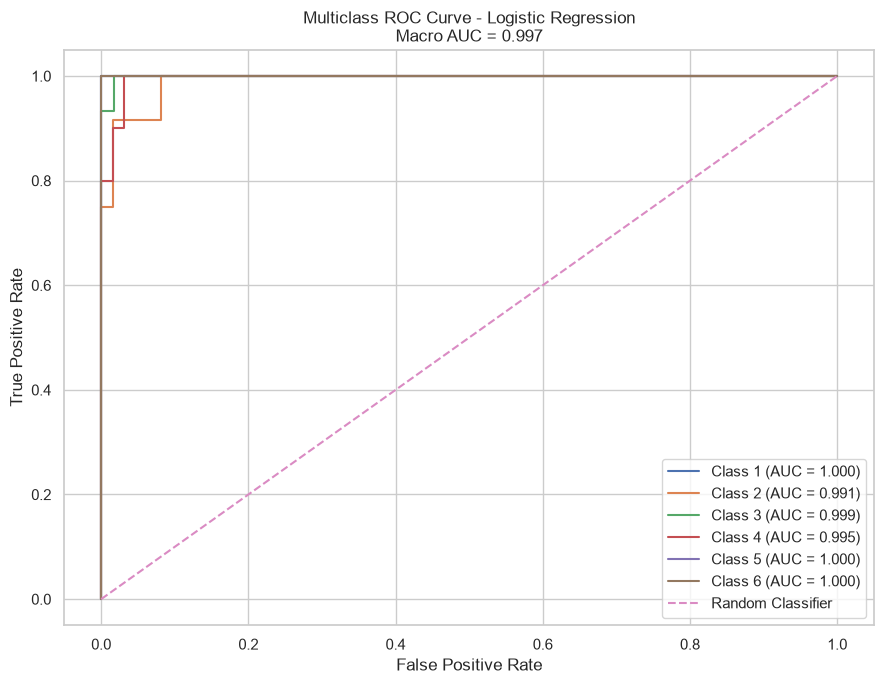

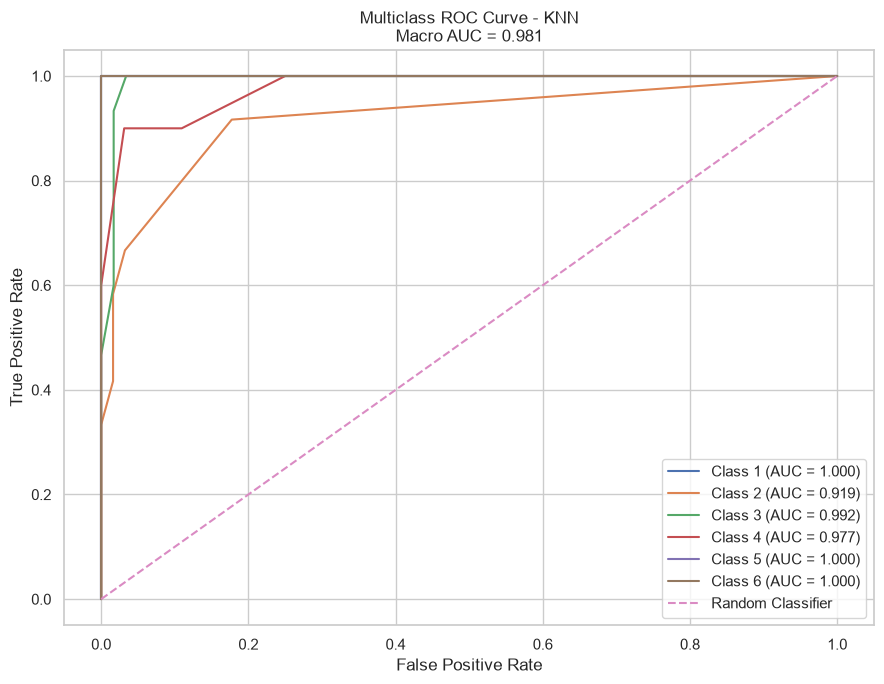

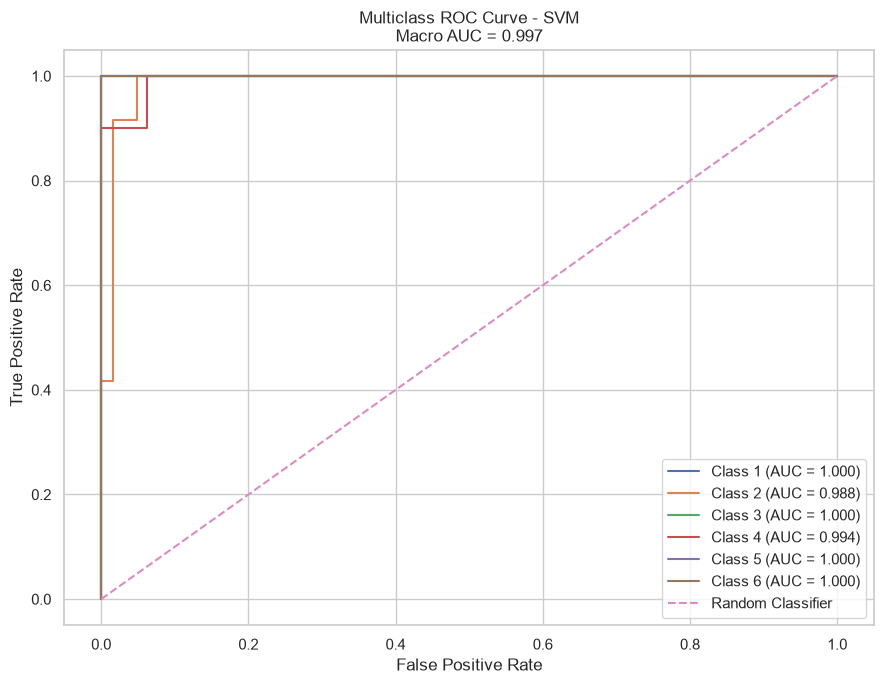

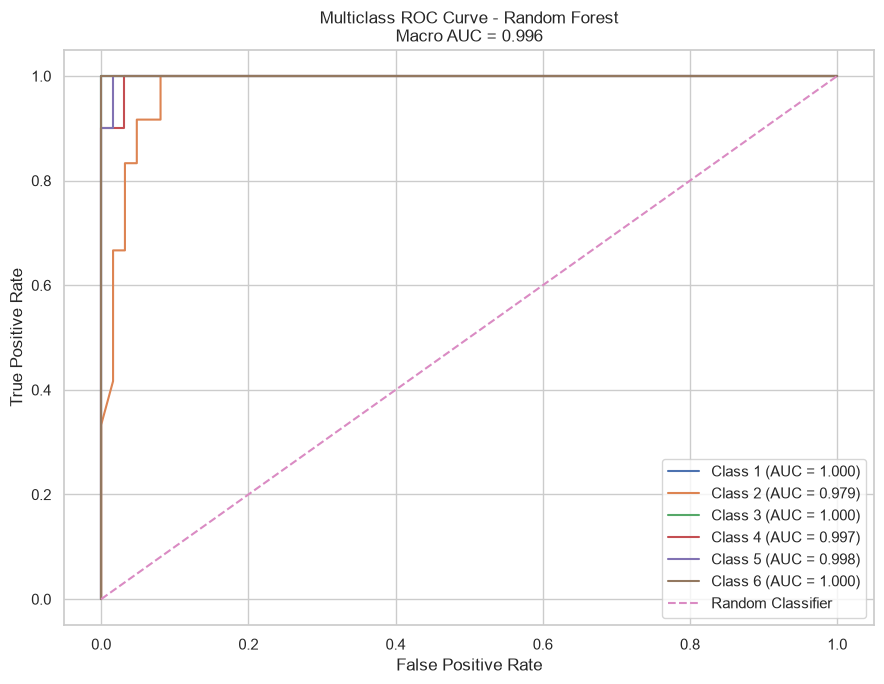

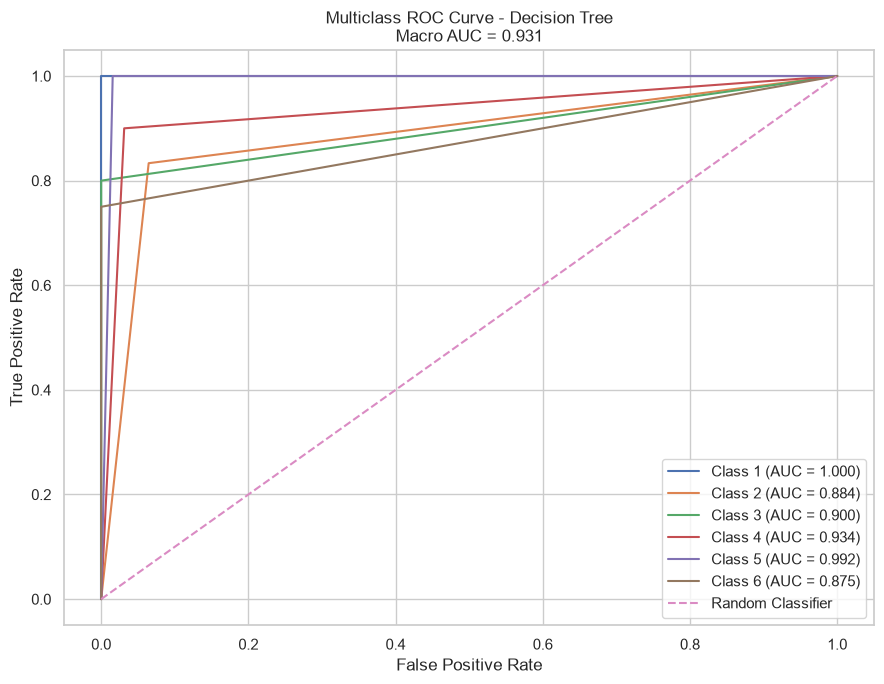

In [106]:
for name, result in roc_results.items():

    plt.figure(figsize=(9, 7))

    for class_label in classes:

        plt.plot(
            result["fpr"][class_label],
            result["tpr"][class_label],
            label=(
                f"Class {class_label} "
                f"(AUC = "
                f"{result['auc'][class_label]:.3f})"
            )
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"Multiclass ROC Curve - {name}\n"
        f"Macro AUC = {result['macro_auc']:.3f}"
    )

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [107]:
auc_results = []

for name, result in roc_results.items():

    auc_results.append({
        "Model": name,
        "Macro AUC": result["macro_auc"]
    })

auc_df = pd.DataFrame(auc_results)

auc_df = auc_df.sort_values(
    "Macro AUC",
    ascending=False
).reset_index(drop=True)

display(auc_df)

,Model,Macro AUC
0,Logistic Regression,0.997462
1,SVM,0.996942
2,Random Forest,0.995747
3,KNN,0.981371
4,Decision Tree,0.930995


In [108]:
final_results = results_df.merge(
    auc_df,
    on="Model"
)

final_results = final_results.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(final_results)

,Model,Accuracy,Precision,Recall,F1 Score,Macro AUC
0,SVM,0.972973,0.969444,0.969444,0.969444,0.996942
1,Logistic Regression,0.959459,0.957176,0.952778,0.954419,0.997462
2,Random Forest,0.945946,0.940404,0.944444,0.941872,0.995747
3,KNN,0.918919,0.917892,0.913889,0.909280,0.981371
4,Decision Tree,0.905405,0.906926,0.880556,0.887464,0.930995


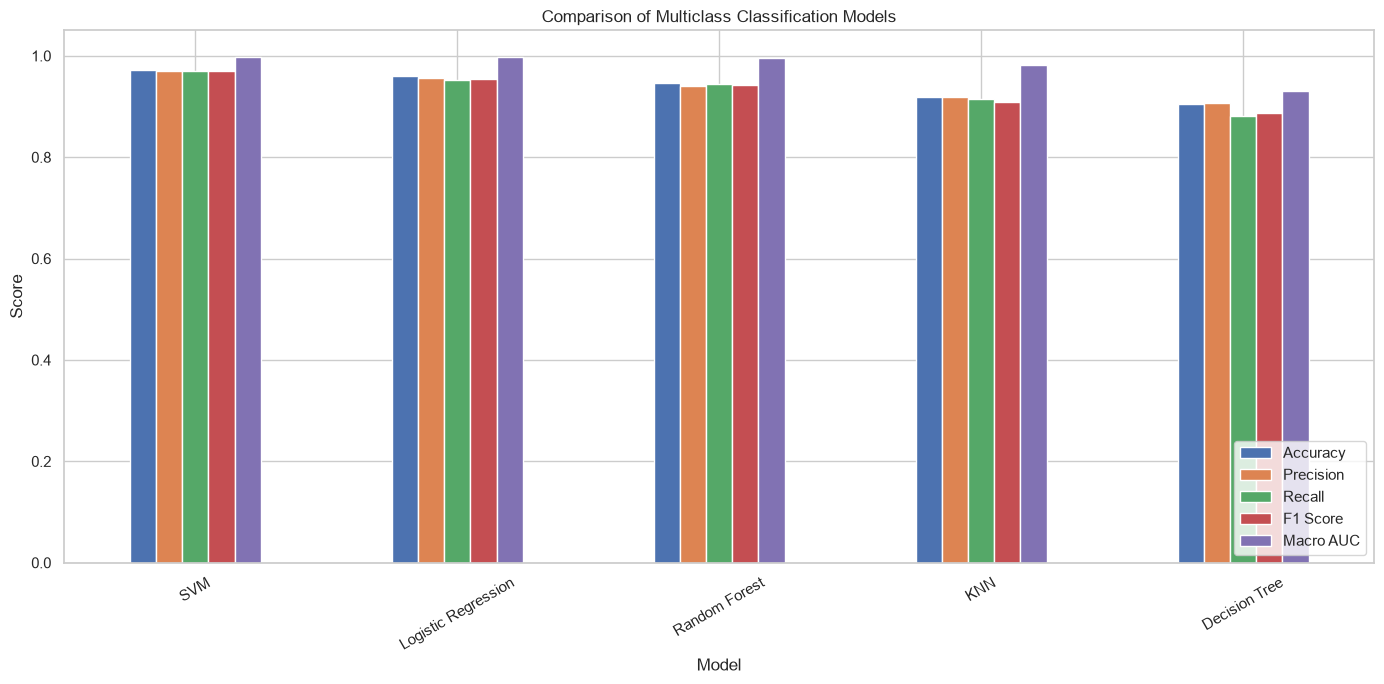

In [109]:
final_results.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Macro AUC"
    ]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Comparison of Multiclass Classification Models"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)

plt.xticks(rotation=30)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [110]:
best_accuracy_model = final_results.loc[
    final_results["Accuracy"].idxmax(),
    "Model"
]

best_precision_model = final_results.loc[
    final_results["Precision"].idxmax(),
    "Model"
]

best_recall_model = final_results.loc[
    final_results["Recall"].idxmax(),
    "Model"
]

best_f1_model = final_results.loc[
    final_results["F1 Score"].idxmax(),
    "Model"
]

best_auc_model = final_results.loc[
    final_results["Macro AUC"].idxmax(),
    "Model"
]

print("Best Accuracy Model:", best_accuracy_model)
print("Best Precision Model:", best_precision_model)
print("Best Recall Model:", best_recall_model)
print("Best F1 Score Model:", best_f1_model)
print("Best Macro AUC Model:", best_auc_model)

Best Accuracy Model: SVM
Best Precision Model: SVM
Best Recall Model: SVM
Best F1 Score Model: SVM
Best Macro AUC Model: Logistic Regression


In [111]:
best_model_name = best_f1_model

print("Best Overall Model:", best_model_name)
print()

print(
    classification_report(
        y_test,
        predictions[best_model_name],
        digits=4
    )
)

Best Overall Model: SVM

              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        23
           2     0.9167    0.9167    0.9167        12
           3     1.0000    1.0000    1.0000        15
           4     0.9000    0.9000    0.9000        10
           5     1.0000    1.0000    1.0000        10
           6     1.0000    1.0000    1.0000         4

    accuracy                         0.9730        74
   macro avg     0.9694    0.9694    0.9694        74
weighted avg     0.9730    0.9730    0.9730        74



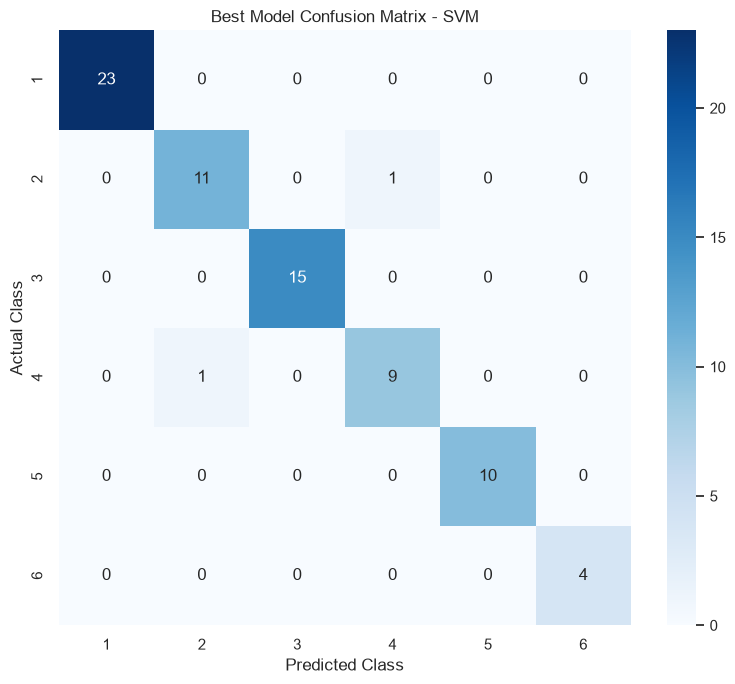

In [112]:
best_cm = confusion_matrix(
    y_test,
    predictions[best_model_name],
    labels=classes
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(
    f"Best Model Confusion Matrix - "
    f"{best_model_name}"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [113]:
best_auc = roc_results[best_model_name]["macro_auc"]

print("Best Model:", best_model_name)

print(
    "Accuracy:",
    round(
        final_results.loc[
            final_results["Model"] == best_model_name,
            "Accuracy"
        ].iloc[0],
        4
    )
)

print(
    "Precision:",
    round(
        final_results.loc[
            final_results["Model"] == best_model_name,
            "Precision"
        ].iloc[0],
        4
    )
)

print(
    "Recall:",
    round(
        final_results.loc[
            final_results["Model"] == best_model_name,
            "Recall"
        ].iloc[0],
        4
    )
)

print(
    "F1 Score:",
    round(
        final_results.loc[
            final_results["Model"] == best_model_name,
            "F1 Score"
        ].iloc[0],
        4
    )
)

print(
    "Macro AUC:",
    round(best_auc, 4)
)

Best Model: SVM
Accuracy: 0.973
Precision: 0.9694
Recall: 0.9694
F1 Score: 0.9694
Macro AUC: 0.9969


In [114]:
disease_names = {
    1: "Psoriasis",
    2: "Seboreic Dermatitis",
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Cronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"
}

class_distribution_named = class_counts.rename(
    index=disease_names
)

display(
    class_distribution_named.to_frame(
        "Number of Samples"
    )
)

,Number of Samples
class,
Psoriasis,112
Seboreic Dermatitis,61
Lichen Planus,72
Pityriasis Rosea,49
Cronic Dermatitis,52
Pityriasis Rubra Pilaris,20


In [115]:
best_report = classification_report(
    y_test,
    predictions[best_model_name],
    output_dict=True
)

class_performance = []

for class_label in classes:

    class_performance.append({
        "Class": class_label,
        "Disease": disease_names[class_label],
        "Precision": best_report[str(class_label)]["precision"],
        "Recall": best_report[str(class_label)]["recall"],
        "F1 Score": best_report[str(class_label)]["f1-score"],
        "Support": best_report[str(class_label)]["support"]
    })

class_performance_df = pd.DataFrame(
    class_performance
)

display(class_performance_df)

,Class,Disease,Precision,Recall,F1 Score,Support
0,1,Psoriasis,1.000000,1.000000,1.000000,23.0
1,2,Seboreic Dermatitis,0.916667,0.916667,0.916667,12.0
2,3,Lichen Planus,1.000000,1.000000,1.000000,15.0
3,4,Pityriasis Rosea,0.900000,0.900000,0.900000,10.0
4,5,Cronic Dermatitis,1.000000,1.000000,1.000000,10.0
5,6,Pityriasis Rubra Pilaris,1.000000,1.000000,1.000000,4.0


In [116]:
final_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

class_performance_df.to_csv(
    "class_performance_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [117]:
print("=" * 70)
print("CSET343 - AI IN HEALTHCARE")
print("LAB ASSIGNMENT 5 - MULTICLASS CLASSIFICATION")
print("=" * 70)

print("\nDataset: Dermatology")
print("Number of classes:", len(classes))
print("Number of samples:", len(df))
print("Number of features:", len(feature_columns))

print("\nBest Overall Model:", best_model_name)

best_row = final_results[
    final_results["Model"] == best_model_name
].iloc[0]

print("\nPerformance:")
print("Accuracy :", round(best_row["Accuracy"], 4))
print("Precision:", round(best_row["Precision"], 4))
print("Recall   :", round(best_row["Recall"], 4))
print("F1 Score :", round(best_row["F1 Score"], 4))
print("Macro AUC:", round(best_row["Macro AUC"], 4))

print("\nAll models:")
display(final_results)

CSET343 - AI IN HEALTHCARE
LAB ASSIGNMENT 5 - MULTICLASS CLASSIFICATION

Dataset: Dermatology
Number of classes: 6
Number of samples: 366
Number of features: 34

Best Overall Model: SVM

Performance:
Accuracy : 0.973
Precision: 0.9694
Recall   : 0.9694
F1 Score : 0.9694
Macro AUC: 0.9969

All models:


,Model,Accuracy,Precision,Recall,F1 Score,Macro AUC
0,SVM,0.972973,0.969444,0.969444,0.969444,0.996942
1,Logistic Regression,0.959459,0.957176,0.952778,0.954419,0.997462
2,Random Forest,0.945946,0.940404,0.944444,0.941872,0.995747
3,KNN,0.918919,0.917892,0.913889,0.909280,0.981371
4,Decision Tree,0.905405,0.906926,0.880556,0.887464,0.930995
